<style>
:root{--navy:#102a43;--blue:#184e77;--teal:#2a9d8f;--gold:#e9c46a;--red:#e76f51;--ink:#172033;--pale:#edf5fb}
.hero{padding:38px 42px;border-radius:24px;color:#f8fbff;background:radial-gradient(circle at 92% 8%,rgba(255,255,255,.16) 0 8%,transparent 9%),linear-gradient(125deg,var(--navy),var(--blue) 55%,var(--teal));box-shadow:0 16px 38px #102a433d;font-family:Inter,'Segoe UI',sans-serif}.hero h1{font-size:38px;margin:18px 0 8px;color:white}.chips{display:flex;gap:8px;flex-wrap:wrap}.chips span{padding:6px 13px;border:1px solid #ffffff55;border-radius:999px;background:#ffffff20;font-size:11px;font-weight:800}.grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(205px,1fr));gap:13px;margin-top:24px}.card{padding:14px 16px;border:1px solid #ffffff44;border-radius:12px;background:#ffffff12}.section{margin:28px 0 14px;padding:16px 22px;border-radius:14px;background:linear-gradient(90deg,var(--navy),var(--blue));color:white}.section h2{margin:0;color:white}.call{padding:18px 22px;margin:14px 0;border:1px solid #c9d9e6;border-left:6px solid var(--teal);border-radius:13px;background:var(--pale);color:var(--ink);line-height:1.7}.warn{border-left-color:var(--red);background:#fff2ed}.proof{border-left-color:var(--gold);background:#fff9e9}.metric{display:inline-block;min-width:145px;padding:12px 14px;margin:4px;border-radius:10px;background:#e5f5f2;color:#184e77;text-align:center}.metric b{display:block;font-size:21px}table{font-size:14px}th{background:#184e77!important;color:white!important;text-align:left!important}td,th{padding:9px!important}code{background:#102a4312;padding:2px 5px;border-radius:4px}
</style><div class="hero"><div class="chips"><span>DEEP LEARNING</span><span>PROYECTO 1</span><span>V6</span><span>GRUPO 1 · SECCIÓN 30</span></div><h1>Monitoreo transaccional</h1><p style="font-size:20px">Datos, modelos A/B/C, encoder–decoder y evidencia del valor del orden</p><div class="grid"><div class="card"><b>Institución</b><br>Universidad del Valle de Guatemala</div><div class="card"><b>Curso</b><br>Deep Learning y Sistemas Inteligentes</div><div class="card"><b>Docente</b><br>Kevin Recinos</div><div class="card"><b>Integrantes</b><br>Wilson Alejandro Calderón Argueta · 22018<br>Pablo Daniel Barillas Moreno · 22193</div><div class="card"><b>Datos</b><br>IEEE-CIS · 590,540 transacciones</div><div class="card"><b>Candidato V6</b><br>A</div></div></div>

In [1]:
from pathlib import Path
import json, pandas as pd, numpy as np
from sklearn.metrics import average_precision_score, roc_auc_score
from IPython.display import Image, display, HTML
ROOT=Path.cwd().resolve()
while not (ROOT/'artefactos').exists() and ROOT != ROOT.parent: ROOT=ROOT.parent
R=json.loads((ROOT/'artefactos/v6/resultados_v6.json').read_text(encoding='utf-8'))
VAL=pd.read_csv(ROOT/'artefactos/v6/predicciones_validacion_v6.csv')
BENCH=pd.read_csv(ROOT/'artefactos/v6/predicciones_benchmark_v6.csv')
print('Fuente única cargada · candidato:',R['candidato']['modelo'])

Fuente única cargada · candidato: A


<div class="section"><h2>1 · Fuente, alcance e integridad</h2></div>

Los datos proceden de la competencia pública [IEEE-CIS Fraud Detection](https://www.kaggle.com/competitions/ieee-fraud-detection/overview), publicada en Kaggle con datos transaccionales anonimizados proporcionados por Vesta Corporation. Se unen `train_transaction.csv` y `train_identity.csv` mediante `TransactionID` y se ordenan por `TransactionDT`; ambos campos funcionan como llave y reloj, no como magnitudes predictivas.

<div class="call warn"><b>Alcance inferencial.</b> El 15 % final es un benchmark temporal histórico reutilizado después de V1–V5. Las decisiones V6 se toman dentro de validación; una afirmación confirmatoria exige una cohorte futura.</div>

Para toda variable histórica se exige causalidad:

$$x_t^{hist}=f(\{x_j:t_j<t\}).$$

In [2]:
pd.DataFrame(R['datos']['particiones']).T

,n,prevalencia,dt_min,dt_max
train,413378.0,0.035169,86400.0,10437996.0
validation,88581.0,0.034341,10438003.0,13151840.0
benchmark_historico,88581.0,0.034804,13151880.0,15811131.0


<div class="section"><h2>2 · Diagnóstico exploratorio y selección de variables</h2></div>

El EDA ejecutado se entrega en `EDA_IEEE_CIS_Diagnostico_Datos_V6.ipynb`. Revisa faltantes, constantes, deriva temporal, correlación de Spearman, asociación con fraude, cobertura de identidades proxy y PCA sobre el bloque `V`. Los IDs se excluyen como predictores. La correlación y PCA son herramientas de diagnóstico, no filtros automáticos: dos variables correlacionadas pueden aportar interacciones diferentes a árboles y conservar varianza no garantiza conservar señal discriminativa.

La V6 amplía variables `C`, `D`, `V`, identidad, faltantes, frecuencia y velocidad en 1/6/24/72 horas. Toda estadística de entidad excluye la transacción actual.

In [3]:
pd.Series(R['secuencias']).to_frame('valor')

,valor
entidad_proxy,"[card1, card2, card3, card5, addr1]"
identidad_aproximada,True
longitud_maxima,32
porcentaje_con_3,88.388424
porcentaje_con_8,76.324889
porcentaje_con_16,66.215328
porcentaje_con_32,55.285163
entidades,42946
mediana_transacciones_entidad,2.0
p90_transacciones_entidad,21.0


<div class="section"><h2>3 · Núcleo comparable A/B y controles</h2></div>

| Pieza | Diseño V6 | Papel experimental |
|---|---|---|
| **A** | Baseline tabular sin orden; seleccionado: `A_V4` | Establece cuánto se logra con variables actuales y agregados causales |
| **B** | GRU frente a TCN causal; seleccionado: `B_TCN` | Puede explotar transiciones en hasta 32 eventos |
| **C** | Fusión A/B/D condicionada por identidad y longitud | Apuesta predeclarada de complementariedad |
| **D** | Encoder–decoder PyTorch entrenado solo con legítimas | Error de reconstrucción como score de anomalía |
| **Control** | Regresión logística | Verifica si la complejidad tabular es necesaria |

Todos producen puntajes continuos sobre las mismas filas, horizonte y etiqueta. Imputación, vocabularios y escalado se ajustan exclusivamente con entrenamiento.

In [4]:
pd.DataFrame(R['seleccion']).T

,opciones_auc_pr_model_select,auc_pr_subventanas_model_select,seleccionado,regla,ganancia_minima_exigida
A,"{'A_V4': 0.607841461381805, 'A_logistica': 0.5...","{'A_V4': [0.6333850481833535, 0.59149619222835...",A_V4,ganancia global >= mínima y no degradar ningun...,0.002
B,"{'B_GRU': 0.48538786335587913, 'B_TCN': 0.5198...",NaN,B_TCN,NaN,NaN


<div class="section"><h2>4 · Encoder–decoder para la clase minoritaria</h2></div>

D aprende una representación latente de transacciones no fraudulentas y minimiza:

$$\mathcal{L}_{AE}=rac{1}{p}\sum_{j=1}^{p}(x_j-\hat{x}_j)^2.$$

Una transacción recibe el error $e(x)$ y este se transforma en percentil respecto de errores legítimos de entrenamiento. Un percentil alto indica que la observación se aleja del patrón normal; no implica fraude por sí solo. Esta estrategia ayuda solo si las anomalías coinciden con fraudes y no con cambios legítimos, faltantes o deriva.

In [5]:
pd.DataFrame(R['entrenamiento_D'])

,epoch,train_mse,early_legit_mse
0,1,0.393435,0.209235
1,2,0.145624,0.104122
2,3,0.099018,0.073824
3,4,0.080287,0.057371
4,5,0.070879,0.050260
5,6,0.065507,0.044821
6,7,0.061114,0.040828
7,8,0.057818,0.038163


<div class="section"><h2>5 · Hipótesis previa, calibración y umbral</h2></div>

<div class="call proof"><b>Hipótesis C.</b> Creemos que una fusión condicionada por la calidad de identidad e historial mejorará AUC-PR y costo porque el puntaje secuencial solo debería influir cuando la historia sea suficientemente fiable. La consideraremos útil si incrementa AUC-PR al menos 0.01 y reduce el costo al menos 5% frente al mejor modelo individual, manteniendo recall mayor o igual a 0.75.</div>

Los scores se calibran en un bloque independiente y el umbral minimiza:

$$C(	au)=Q4{,}200\,FN(	au)+Q180\,FP(	au),$$

sujeto al objetivo de recall declarado. AP es la métrica principal porque el fraude es minoritario; ROC-AUC se reporta como discriminación global, pero puede ocultar muchas falsas alarmas.

In [6]:
pd.DataFrame(R['calibracion']).T

,brier_raw,brier_calibrado
A,0.023674,0.023674
B,0.033774,0.026073
C,0.023876,0.023712
D,0.415058,0.031872


<div class="section"><h2>6 · Resultados comunes</h2></div>

La precisión indica qué proporción de alertas es fraude; el recall, qué proporción de fraudes se detecta; F1 equilibra ambas sin incorporar quetzales. AP resume la curva precisión–recall a través de umbrales y no debe confundirse con precisión puntual.

In [7]:
pd.DataFrame(R['evaluacion_interna']).T[['auc_pr','roc_auc','precision','recall','f1','tp','fp','fn','cost_q','alertas_por_100k','threshold']]

,auc_pr,roc_auc,precision,recall,f1,tp,fp,fn,cost_q,alertas_por_100k,threshold
A,0.536238,0.900800,0.147336,0.803309,0.249003,437.0,2529.0,107.0,904620.0,16740.983236,0.036224
B,0.391528,0.852595,0.110825,0.713235,0.191842,388.0,3113.0,156.0,1215540.0,19760.681831,0.031870
C,0.519202,0.902288,0.165422,0.773897,0.272580,421.0,2124.0,123.0,898920.0,14364.734436,0.039975
D,0.217174,0.758170,0.054355,0.744485,0.101313,405.0,7046.0,139.0,1852080.0,42055.652763,0.029452


In [8]:
eval_rows=np.arange(int(len(VAL)*.80),len(VAL))
for name in ['A','B','C','D']:
    measured=average_precision_score(VAL.y.to_numpy()[eval_rows],VAL[f'score_{name}'].to_numpy()[eval_rows])
    assert abs(measured-R['evaluacion_interna'][name]['auc_pr'])<1e-10
print('Coherencia verificada: AP reproducida desde los scores guardados.')

Coherencia verificada: AP reproducida desde los scores guardados.


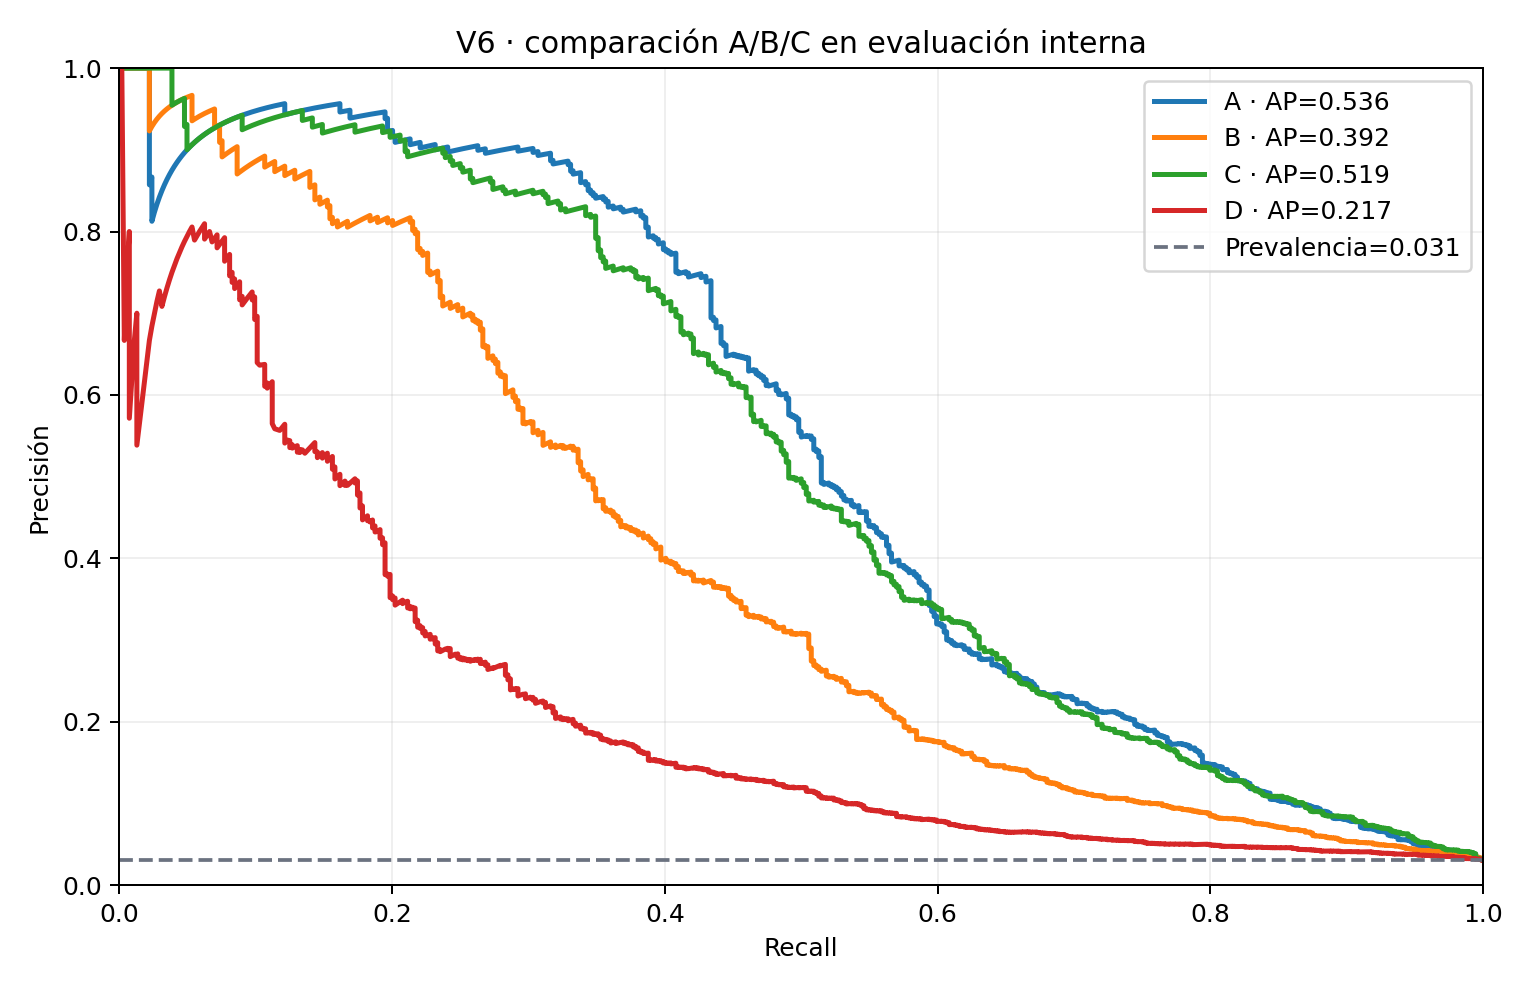

In [9]:
display(Image(filename=str(ROOT/'evidencia/figuras/v6/01_comparacion_abc_validacion.png')))

<div class="section"><h2>7 · Dos intentos de falsificar el valor del orden</h2></div>

Se barajan únicamente los antecedentes, nunca la transacción objetivo, con cinco semillas. Además se recorta la historia a 3, 8 y 16 eventos. La caída original–permutada fue `-0.0101` AP y no alcanzó el umbral material predeclarado de 0.01. Esta prueba distingue “una red que procesa secuencias” de “un modelo cuya predicción depende realmente del orden”.

In [10]:
pd.DataFrame({'original':R['falsificaciones']['original_internal'],'permutada':{'auc_pr':R['falsificaciones']['permutation_mean_auc_pr']},'historia_3':R['falsificaciones']['historia_3'],'historia_8':R['falsificaciones']['historia_8'],'historia_16':R['falsificaciones']['historia_16']}).T

,auc_pr,roc_auc,precision,recall,f1,tn,fp,fn,tp,cost_q,cost_per_decision_q,alertas_por_100k,threshold
original,0.391528,0.852595,0.110825,0.713235,0.191842,14060.0,3113.0,156.0,388.0,1215540.0,68.608681,19760.681831,0.03187
permutada,0.401601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
historia_3,0.384743,0.855529,0.121571,0.716912,0.207889,14355.0,2818.0,154.0,390.0,1154040.0,65.137439,18106.902975,0.03187
historia_8,0.377367,0.851992,0.122598,0.680147,0.207748,14525.0,2648.0,174.0,370.0,1207440.0,68.151493,17034.486651,0.03187
historia_16,0.386030,0.852787,0.115828,0.702206,0.198855,14257.0,2916.0,162.0,382.0,1205280.0,68.029576,18614.889654,0.03187


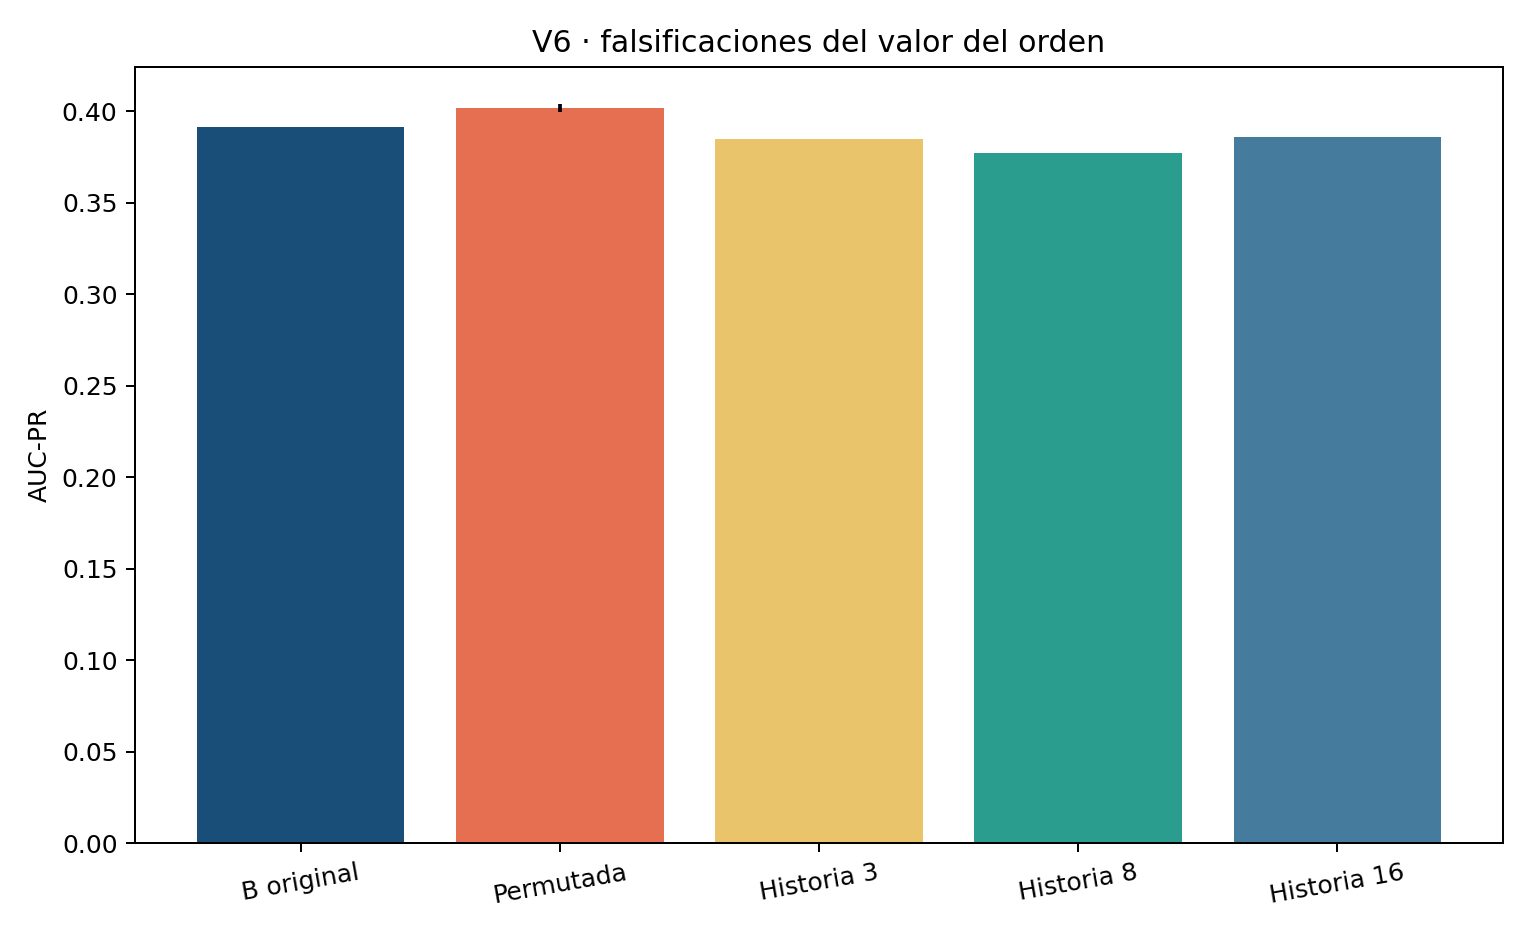

In [11]:
display(Image(filename=str(ROOT/'evidencia/figuras/v6/03_falsificaciones_orden_v6.png')))

<div class="section"><h2>8 · Decisión económica y veredicto</h2></div>

C no cumplió el criterio previo. El candidato `A` fue elegido por la regla congelada en evaluación interna; las cifras del benchmark son descriptivas y no reabren la selección. Un ROC-AUC alto puede coexistir con baja precisión cuando la clase negativa domina: por eso se muestran alertas por 100,000 y costo, no solo métricas de ranking.

In [12]:
pd.DataFrame(R['benchmark_historico']).T[['auc_pr','roc_auc','precision','recall','f1','tp','fp','fn','cost_q','alertas_por_100k']]

,auc_pr,roc_auc,precision,recall,f1,tp,fp,fn,cost_q,alertas_por_100k
A,0.559156,0.901268,0.157788,0.807006,0.263965,2488.0,13280.0,595.0,4889400.0,17800.657026
B,0.465388,0.876691,0.122706,0.784950,0.212234,2420.0,17302.0,663.0,5898960.0,22264.368205
C,0.563199,0.907028,0.171427,0.798248,0.282241,2461.0,11895.0,622.0,4753500.0,16206.635735
D,0.228690,0.769198,0.056073,0.823873,0.105000,2540.0,42758.0,543.0,9977040.0,51137.377090


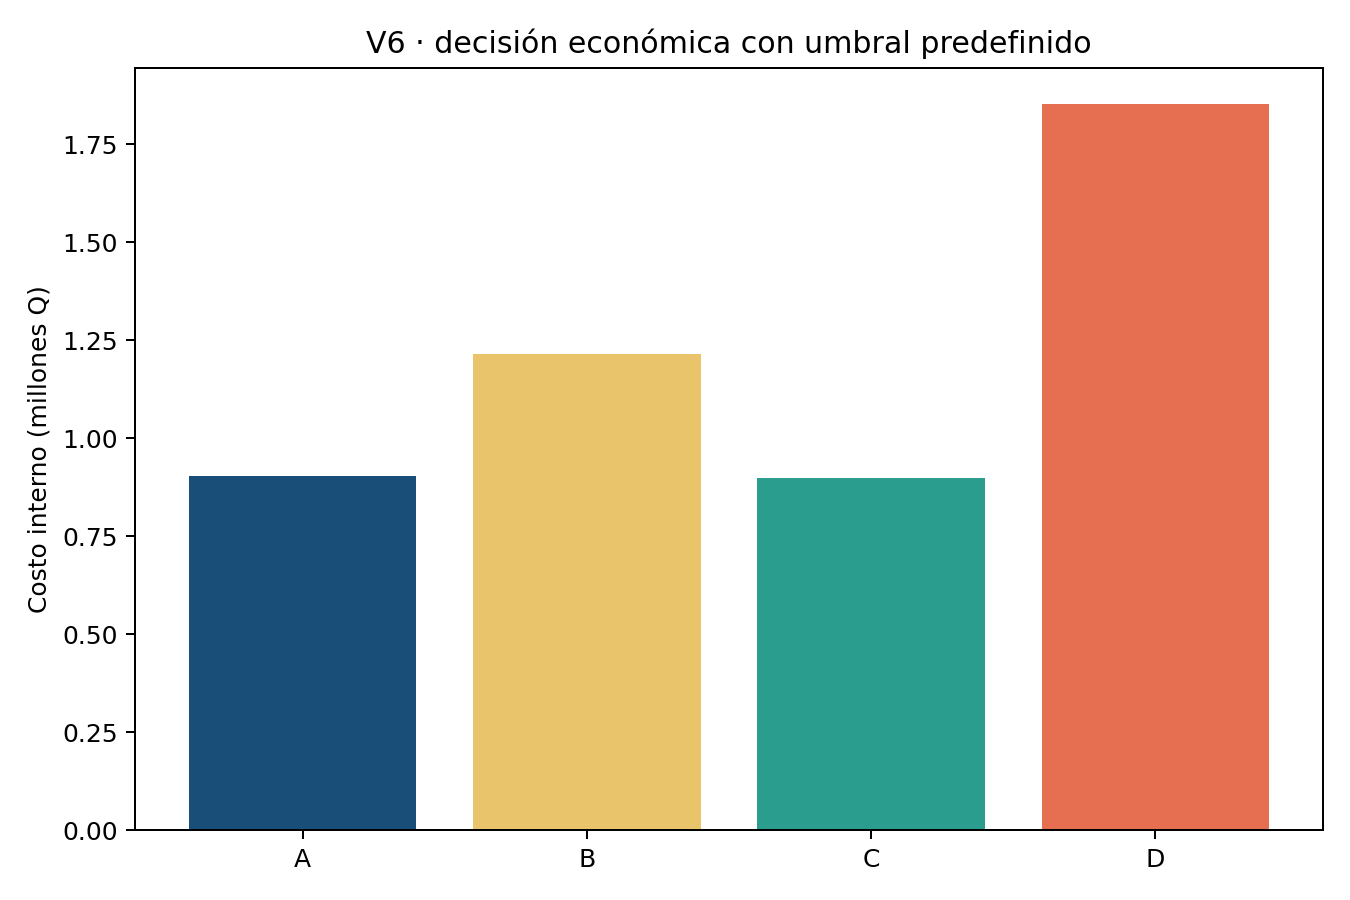

In [13]:
display(Image(filename=str(ROOT/'evidencia/figuras/v6/04_costos_abc_v6.png')))

<div class="section"><h2>9 · Matriz de evidencias y conclusión</h2></div>

| Evidencia rubricada | Resultado verificable | Decisión o límite |
|---|---|---|
| Integridad | 70/15/15 temporal; transformaciones train-only | Benchmark reutilizado, no ciego |
| A/B común | Misma población, horizonte y scores continuos | AP principal; costo en umbral |
| Orden | 5 permutaciones + recortes 3/8/16 | Solo se atribuye valor con caída material |
| C | Regla +0.01 AP, −5 % costo y recall ≥0.75 | Veredicto no reescrito con benchmark |
| D | Reconstrucción de legítimas | Anomalía no equivale automáticamente a fraude |
| Economía | Q4,200 FN y Q180 FP | Escenario académico sensible al volumen |

La recomendación final debe leerse junto con limitaciones: identidad proxy, anonimización, deriva, benchmark reutilizado y ausencia de auditoría productiva de equidad, privacidad, latencia y seguridad.

<div class="section"><h2>10 · Reproducibilidad, IA y referencias</h2></div>

Pipeline: `python -u codigo/v6/proyecto1_v6_pipeline.py`. Auditoría: `python codigo/v6/audit_project1_v6.py`. Los artefactos incluyen modelos, calibradores, umbrales, predicciones, contrato y manifiesto.

**Declaración de uso de inteligencia artificial.** Se utilizó asistencia para estructurar código, revisar consistencia, redactar y automatizar documentación. Los autores ejecutaron, verificaron y deben defender datos, decisiones, métricas y conclusiones.

**Referencias APA 7**

IEEE Computational Intelligence Society. (2019). *IEEE-CIS Fraud Detection* [Data set]. Kaggle. https://www.kaggle.com/competitions/ieee-fraud-detection/overview

Ke, G., et al. (2017). LightGBM: A highly efficient gradient boosting decision tree. *Advances in Neural Information Processing Systems, 30*.

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432

Zhou, C., & Paffenroth, R. C. (2017). Anomaly detection with robust deep autoencoders. *Proceedings of the 23rd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 665–674. https://doi.org/10.1145/3097983.3098052